# 日経平均株価 先物（CME日経先物 円建て）15分足

In [1]:
import sys

path_up = ".."
if not path_up in sys.path:
    sys.path.append(path_up)

In [2]:
import os

import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import mplfinance as mpf
import pandas as pd
import yfinance as yf

In [3]:
symbol = "NIY=F"
ticker1 = yf.Ticker(symbol)
df = ticker1.history(period="1d", interval="15m")
df.index = df.index.tz_convert("Asia/Tokyo")
df

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Datetime,,,,,,,
2026-06-10 13:00:00+09:00,64335.0,64345.0,64240.0,64240.0,103,0.0,0.0
2026-06-10 13:15:00+09:00,64255.0,64335.0,64070.0,64070.0,493,0.0,0.0
2026-06-10 13:30:00+09:00,64035.0,64100.0,63840.0,63850.0,665,0.0,0.0
2026-06-10 13:45:00+09:00,63840.0,64145.0,63775.0,63910.0,603,0.0,0.0
2026-06-10 14:00:00+09:00,63920.0,64135.0,63830.0,63980.0,288,0.0,0.0
...,...,...,...,...,...,...,...
2026-06-11 03:15:00+09:00,63890.0,63925.0,63745.0,63845.0,641,0.0,0.0
2026-06-11 03:30:00+09:00,63825.0,63825.0,63650.0,63660.0,262,0.0,0.0
2026-06-11 03:45:00+09:00,63660.0,63695.0,63520.0,63565.0,261,0.0,0.0


In [4]:
# 先頭のタイムスタンプ（例：金曜のどこかの時刻）
dt0 = df.index[0]

# 金曜の日付だけを取り出す
fri = dt0.normalize()  # 00:00 に丸める

# 開始・終了
dt_start = fri + pd.Timedelta(hours=15, minutes=30)
dt_end = fri + pd.Timedelta(days=1, hours=6)
print(dt_start)
print(dt_end)

df = df[(dt_start <= df.index) & (df.index < dt_end)]
df

2026-06-10 15:30:00+09:00
2026-06-11 06:00:00+09:00


,Open,High,Low,Close,Volume,Dividends,Stock Splits
Datetime,,,,,,,
2026-06-10 15:30:00+09:00,64310.0,64360.0,64190.0,64310.0,495,0.0,0.0
2026-06-10 15:45:00+09:00,64320.0,64360.0,64300.0,64325.0,159,0.0,0.0
2026-06-10 16:00:00+09:00,64335.0,64375.0,64225.0,64330.0,358,0.0,0.0
2026-06-10 16:15:00+09:00,64340.0,64355.0,64215.0,64280.0,377,0.0,0.0
2026-06-10 16:30:00+09:00,64285.0,64415.0,64270.0,64280.0,86,0.0,0.0
2026-06-10 16:45:00+09:00,64280.0,64310.0,64190.0,64310.0,80,0.0,0.0
2026-06-10 17:00:00+09:00,64290.0,64305.0,63970.0,64035.0,325,0.0,0.0
2026-06-10 17:15:00+09:00,64055.0,64075.0,63875.0,63970.0,663,0.0,0.0
2026-06-10 17:30:00+09:00,63975.0,64005.0,63735.0,63745.0,620,0.0,0.0


In [5]:
year_str = f"{dt_end.year:04d}"
month_str = f"{dt_end.month:02d}"
day_str = f"{dt_end.day:02d}"
output_path = os.path.join(year_str, month_str, day_str)
os.makedirs(output_path, exist_ok=True)
output_path

'2026/06/11'

## ローソク足チャート（小さいサイズ）

In [6]:
FONT_PATH = "../fonts/RictyDiminished-Regular.ttf"
fm.fontManager.addfont(FONT_PATH)

# FontPropertiesオブジェクト生成（名前の取得のため）
font_prop = fm.FontProperties(fname=FONT_PATH)
font_prop.get_name()

plt.rcParams["font.family"] = font_prop.get_name()
plt.rcParams["font.size"] = 8

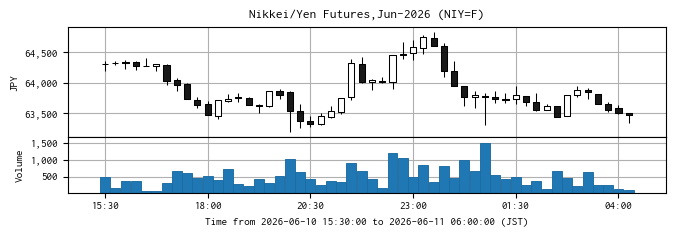

In [7]:
fig = plt.figure(figsize=(6.8, 2.4))
ax = dict()
n = 2
gs = fig.add_gridspec(
    n, 1, wspace=0.0, hspace=0.0, height_ratios=[2 if i == 0 else 1 for i in range(n)]
)
for i, axis in enumerate(gs.subplots(sharex="col")):
    ax[i] = axis
    ax[i].grid()

mpf.plot(
    df,
    type="candle",
    style="default",
    datetime_format="%H:%M",
    xrotation=0,
    update_width_config=dict(candle_linewidth=0.75),
    volume=ax[1],
    ax=ax[0],
)
ax[0].yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.0f}"))
ax[1].yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.0f}"))

ax[1].set_xlabel(
    f"Time from {dt_start.replace(tzinfo=None)} "
    f"to {dt_end.replace(tzinfo=None)} (JST)"
)
ax[0].set_ylabel("JPY")

if "shortName" in ticker1.info:
    ax[0].set_title(f"{ticker1.info['shortName']} ({symbol})")
elif "longName" in ticker1.info:
    ax[0].set_title(f"{ticker1.info['longName']} ({symbol})")
else:
    ax[0].set_title(f"{symbol}")

plt.tight_layout()
plt.savefig(os.path.join(output_path, f"15min_chart_{symbol}.png"))
plt.show()